<!-- auditkit-logo-cell -->
<p align="center">
  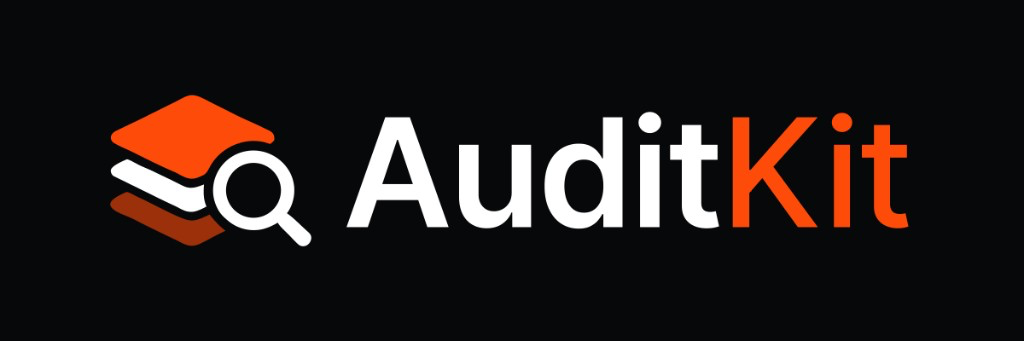
</p>

# Application — pruning degradation on real BoolQ (Llama-3.2-3B)

Does structurally pruning 20/40/60% of a real Llama-3.2-3B's MLP neurons
actually degrade real BoolQ accuracy the way the model cards claim? The 4
models compared here are real local checkpoints (pruning isn't something a
hosted API can do), scored with a custom answer-match metric, grounding
via `LexicalGroundedness`, and a real, local, gated Hugging Face Llama model as an
independent judge.
20 real BoolQ questions, `RunConfig(track_performance=True)` for real
latency/size numbers, and `ak.compare_models()` end to end.


In [ ]:
# Colab bootstrap -- clones and installs auditkit from source. No-op outside Colab.
import sys, subprocess, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import getpass
    REPO_DIR = "/content/AuditKit-mirror"
    if not os.path.exists(REPO_DIR):
        github_token = getpass.getpass(
            "GitHub personal access token (repo is private -- needs 'repo' read scope): "
        )
        repo_url = f"https://{github_token}@github.com/utsavavaiya-sudo/AuditKit-mirror.git"
        clone = subprocess.run(
            ["git", "clone", "-b", "continue-removal-branch", "-q", repo_url, REPO_DIR],
            capture_output=True, text=True,
        )
        if clone.returncode != 0:
            raise RuntimeError(
                "git clone failed:\n" + clone.stderr.replace(github_token, "<redacted>") +
                "\nCommon causes: token missing 'repo' scope, or not a collaborator on this repo."
            )
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", f"{REPO_DIR}[transformers,interop,lmeval,groq]"], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, f"{REPO_DIR}/src")
    print("Colab detected -- auditkit installed from source at", REPO_DIR)
else:
    print("Not running in Colab -- assuming auditkit is already installed locally with [transformers,interop,lmeval,groq].")


In [ ]:
import os
import getpass

import auditkit as ak
from auditkit import Sample
from auditkit.model.hf_gen import HFGenModel

# meta-llama/Llama-3.2-3B is gated -- needs a token from an account that
# accepted the license at huggingface.co/meta-llama/Llama-3.2-3B.
HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass("HF token (gated model): ")
# TODO (model migration): JUDGE_MODEL was "groq:openai/gpt-oss-20b" -- Groq is
# no longer used anywhere else in this repo's notebooks. Moved to a real, local,
# gated Llama checkpoint, distinct from all 4 compared models, so the judge never
# grades a sibling model. Untested at this size alongside 4 other loaded models --
# watch GPU memory (each model is loaded/evaluated/freed one at a time).
JUDGE_MODEL = HFGenModel(model="meta-llama/Meta-Llama-3-8B-Instruct", hf_token=HF_TOKEN, device="cuda")

print("auditkit version:", ak.__version__)


---
## Real dataset — `google/boolq`, 20 real yes/no questions


In [ ]:
from datasets import load_dataset

boolq_ds = load_dataset("google/boolq", split="validation")
N = 20
boolq_samples = [
    Sample(input=row["question"], target="yes" if row["answer"] else "no",
           retrieval_context=[row["passage"]], id=str(i))
    for i, row in enumerate(boolq_ds.select(range(N)))
]
print(f"{len(boolq_samples)} real BoolQ samples")


---
## Annotator + custom metrics

Base (non-instruct) checkpoints continue the prompt rather than repeating
"Answer:", so the regex anchors to the *start* of the completion.
`NotDegenerateOutput` checks for a real, well-known symptom of
aggressively pruned models: collapsing into an immediate word-repetition
loop -- a failure mode specific to pruning, not a generic bolt-on metric.


In [ ]:
import re

from auditkit.annotator import RegexAnnotator
from auditkit.metric import Metric
from auditkit.score import Score
from auditkit.types import Direction, ScoreKind

answer_extractor = RegexAnnotator(pattern=r"^\s*(yes|no)", flags=re.IGNORECASE, group=1, name="answer_extractor")


class BoolQAnswerMatch(Metric):
    """1.0 iff the extracted yes/no matches the real label."""
    name = "boolq_answer_match"
    kind = ScoreKind.CODE
    direction = Direction.MAXIMIZE

    def score(self, sample, output, context=None) -> Score:
        extracted = (context or {}).get("answer_extractor", {}).get("extracted", "")
        correct = extracted.strip().lower() == (sample.target or "").lower()
        return Score(name=self.name, value=1.0 if correct else 0.0, kind=self.kind)


class NotDegenerateOutput(Metric):
    """1.0 iff the output does NOT show immediate word repetition (e.g.
    "no no no") -- a real, well-known symptom of aggressively pruned
    models collapsing into a degenerate loop."""
    name = "not_degenerate_output"
    kind = ScoreKind.CODE
    direction = Direction.MAXIMIZE

    def score(self, sample, output, context=None) -> Score:
        words = output.split()
        degenerate = any(
            len(w) > 1 and w.lower() == words[i + 1].lower() == words[i + 2].lower()
            for i, w in enumerate(words[:-2])
        )
        return Score(name=self.name, value=0.0 if degenerate else 1.0, kind=self.kind)


---
## 4 real local models — baseline + 3 pruning severities — compared via `ak.compare_models()`


In [ ]:
from auditkit.model.hf_gen import HFGenModel
from auditkit.adapter import TemplateAdapter
from auditkit.metrics.rag import LexicalGroundedness
from auditkit.metrics.judge import LLMJudge
from auditkit.runspec import RunConfig

FEWSHOT = ("Passage: Water boils at 100C at sea level.\nQuestion: Does water boil at 100C at sea level?\nAnswer: yes\n\n"
           "Passage: {context}\nQuestion: {input}\nAnswer:")
adapter = TemplateAdapter(FEWSHOT)

all_models = [
    HFGenModel(model="meta-llama/Llama-3.2-3B", device="cuda", hf_token=HF_TOKEN, name="baseline"),
    HFGenModel(model="oopere/pruned20-llama-3.2-3b", device="cuda", name="pruned20"),
    HFGenModel(model="oopere/pruned40-llama-3.2-3b", device="cuda", name="pruned40"),
    HFGenModel(model="oopere/pruned60-llama-3.2-3b", device="cuda", name="pruned60"),
]
model_names = ["baseline", "pruned20", "pruned40", "pruned60"]
config = RunConfig(concurrency=1, temperature=0.0, max_tokens=8, track_performance=True)

judge = LLMJudge(
    judge_model=JUDGE_MODEL, name="factual_correctness_judge",
    prompt="Passage: {context}\nQuestion: {input}\nReal answer: {expected}\nModel answer: {output}\n"
           "Does the model answer match the real answer? Reply CHOICE: yes or CHOICE: no.",
    choices={"yes": 1.0, "no": 0.0}, temperature=0.0,
    max_tokens=200,  # generous budget so the CHOICE line is never truncated
)

cmp = ak.compare_models(
    models=all_models, dataset=boolq_samples, model_names=model_names,
    adapter=adapter, annotators=[answer_extractor],
    scorers=[BoolQAnswerMatch(), LexicalGroundedness(), NotDegenerateOutput(), judge],
    config=config,
    experiment_name="pruned_llama_boolq_application", tags=["application", "pruning", "boolq"],
)
print("Coverage warnings:", cmp.coverage_warnings())


### Per-sample, per-metric breakdown

Raw output, the extracted yes/no, and every metric's individual score for
the first few samples of each model -- what actually drove the headline
numbers above.


In [ ]:
for name in model_names:
    run = cmp.runs.get(name)
    print(f"=== {name} ===")
    if run is None:
        print(f"  (failed: {cmp.errors.get(name)})")
        continue
    for p in run.predictions[:3]:
        scores = {s["name"]: s["value"] for s in p.metadata["scores"]}
        extracted = (p.context or {}).get("answer_extractor", {})
        print(f"  raw output: {p.raw_output[:80]!r}")
        print(f"  extracted:  {extracted.get('extracted')!r} (matched={extracted.get('matched')})")
        print(f"  expected:   {p.expected!r}")
        print(f"  scores:     {scores}")
        print()


### Winner per metric, real performance/size, and ship/no-ship per pruning severity

In [ ]:
for pm in cmp.per_metric():
    print(f"{pm.metric}: winner is {pm.winner}")
print()
print("Performance (measured):")
for row in cmp.performance_table():
    print(row)
print()
print("Coverage warnings:", cmp.coverage_warnings())
print()
print("Model size (measured):")
for row in cmp.size_table():
    print(row)


In [ ]:
for pruned in ["pruned20", "pruned40", "pruned60"]:
    run_cmp = cmp.pairwise("baseline", pruned)
    print(f"=== baseline vs. {pruned} ===  grade={run_cmp.grade()}  "
          f"retention(boolq_answer_match)={run_cmp.retention('boolq_answer_match'):.3f}  "
          f"retention(not_degenerate_output)={run_cmp.retention('not_degenerate_output'):.3f}  "
          f"retention(factual_correctness_judge)={run_cmp.retention('factual_correctness_judge'):.3f}")


---
## Summary

Pruning degradation confirmed several independent ways: the custom
`boolq_answer_match` metric (extracted yes/no vs. real label),
`not_degenerate_output` (catches the real repetition-loop failure mode
aggressive pruning is known to cause -- specific to this study, not a
generic bolt-on), and a real, local `LLMJudge` (a model that never
saw the pruning at all). All three should agree the degradation gets
worse from pruned20 -> pruned60 -- `retention()` and `grade()` above make
it explicit whether each severity still ships. No guard/BERT scorers
here: BoolQ answers are a single word (yes/no), not the long free-text
those scorers need to be meaningful.
